# 01 — Data Exploration

This notebook explores the **MIT-BIH Arrhythmia Database**: what a raw ECG signal looks like, the effect of the band-pass filter, how beats are segmented, the (severe) class imbalance, and the average morphology of each AAMI class.

> Run `python download_data.py` first so the raw records are available in `data/mitdb/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.utils import load_config, AAMI_CLASSES
from src.preprocessing import load_record, bandpass_filter, process_record
from src.visualization import plot_class_distribution, plot_sample_beats

config = load_config('../config.yaml')
RAW_DIR = '../' + config.data['raw_dir']
FS = config.data['sampling_rate']
print('Sampling rate:', FS, 'Hz')

Sampling rate: 360 Hz


## 1. Raw signal and the effect of filtering

We plot the first few seconds of record 100 before and after band-pass filtering. The filter removes low-frequency **baseline wander** and high-frequency noise while preserving the QRS complex.

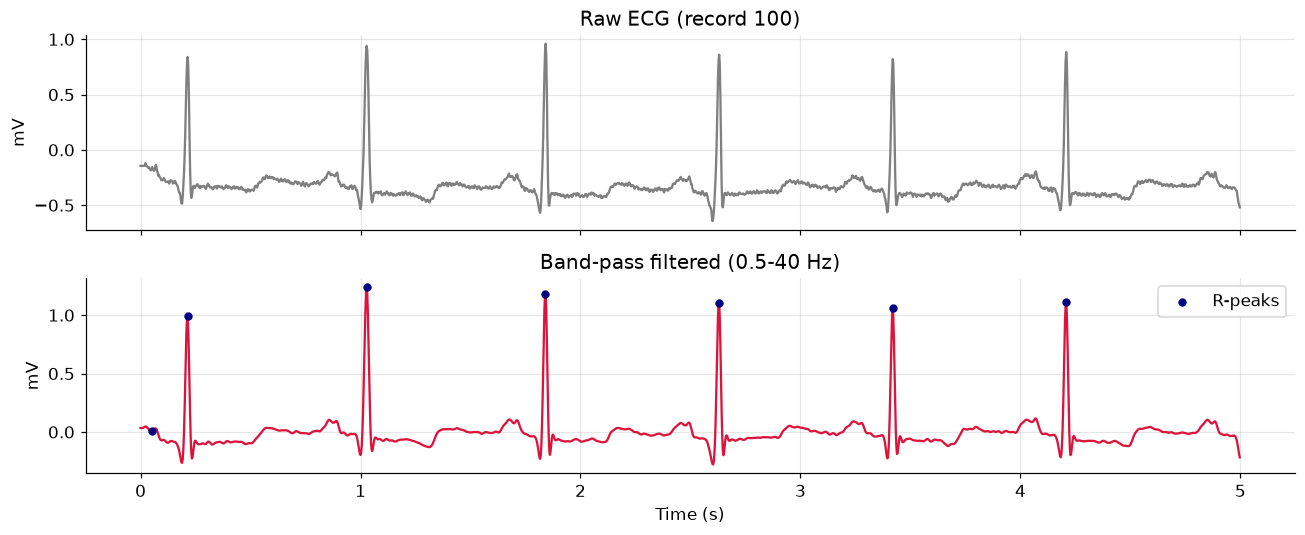

In [2]:
signal, r_peaks, symbols = load_record('100', RAW_DIR, channel=0)
filtered = bandpass_filter(signal, low=0.5, high=40.0, fs=FS)

seconds = 5
n = seconds * FS
t = np.arange(n) / FS
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t, signal[:n], color='gray'); axes[0].set(title='Raw ECG (record 100)', ylabel='mV')
axes[1].plot(t, filtered[:n], color='crimson'); axes[1].set(title='Band-pass filtered (0.5-40 Hz)', xlabel='Time (s)', ylabel='mV')
# Mark the annotated R-peaks in this window.
peaks_in_window = r_peaks[r_peaks < n]
axes[1].scatter(peaks_in_window / FS, filtered[peaks_in_window], color='navy', s=20, zorder=3, label='R-peaks')
axes[1].legend(); plt.tight_layout(); plt.show()

## 2. Class distribution across the whole database

We process every included record and count beats per AAMI class. Note the log scale: **Normal** beats dominate, which is why we use class-weighted loss and macro-F1.

18:39:02 | INFO     | src.preprocessing | Record 100: extracted 2271 beats


18:39:02 | INFO     | src.preprocessing | Record 101: extracted 1864 beats


18:39:02 | INFO     | src.preprocessing | Record 103: extracted 2083 beats


18:39:03 | INFO     | src.preprocessing | Record 105: extracted 2572 beats


18:39:03 | INFO     | src.preprocessing | Record 106: extracted 2027 beats


...

18:39:05 | INFO     | src.preprocessing | Record 231: extracted 1570 beats


18:39:05 | INFO     | src.preprocessing | Record 232: extracted 1780 beats


18:39:05 | INFO     | src.preprocessing | Record 233: extracted 3077 beats


18:39:05 | INFO     | src.preprocessing | Record 234: extracted 2752 beats


Total beats: 100682
  N:  90076  (89.5%)
  S:   2781  (2.8%)
  V:   7008  (7.0%)
  F:    802  (0.8%)
  Q:     15  (0.0%)


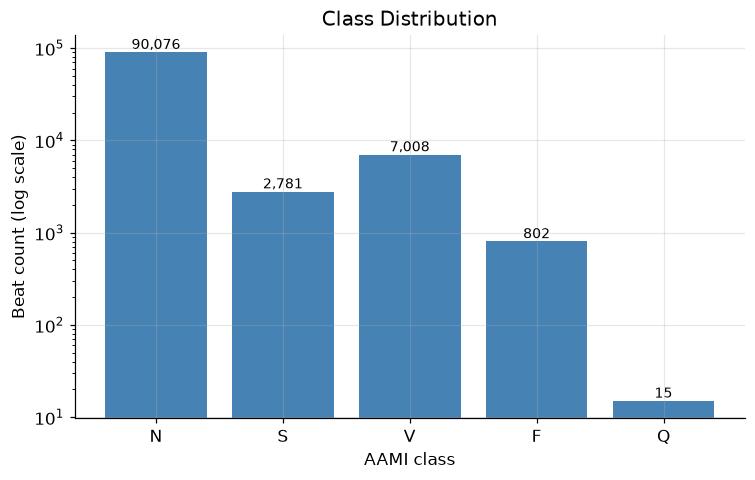

In [3]:
from src.dataset import ALL_RECORDS, CLASS_TO_IDX

excluded = {str(r) for r in config.data['excluded_records']}
records = [r for r in ALL_RECORDS if r not in excluded]

all_signals, all_labels = [], []
for rec in records:
    beats = process_record(rec, RAW_DIR, channel=0, beat_window=config.data['beat_window'])
    for b in beats:
        all_signals.append(b.signal); all_labels.append(CLASS_TO_IDX[b.label])
signals = np.stack(all_signals); labels = np.array(all_labels)
print('Total beats:', len(labels))
for i, c in enumerate(AAMI_CLASSES):
    print(f'  {c}: {(labels==i).sum():>6}  ({(labels==i).mean():.1%})')

plot_class_distribution(labels);

## 3. Sample beats per class

A visual check that segmentation is centred on the R-peak and that classes are morphologically distinguishable (e.g. ventricular beats have a wider, taller QRS).

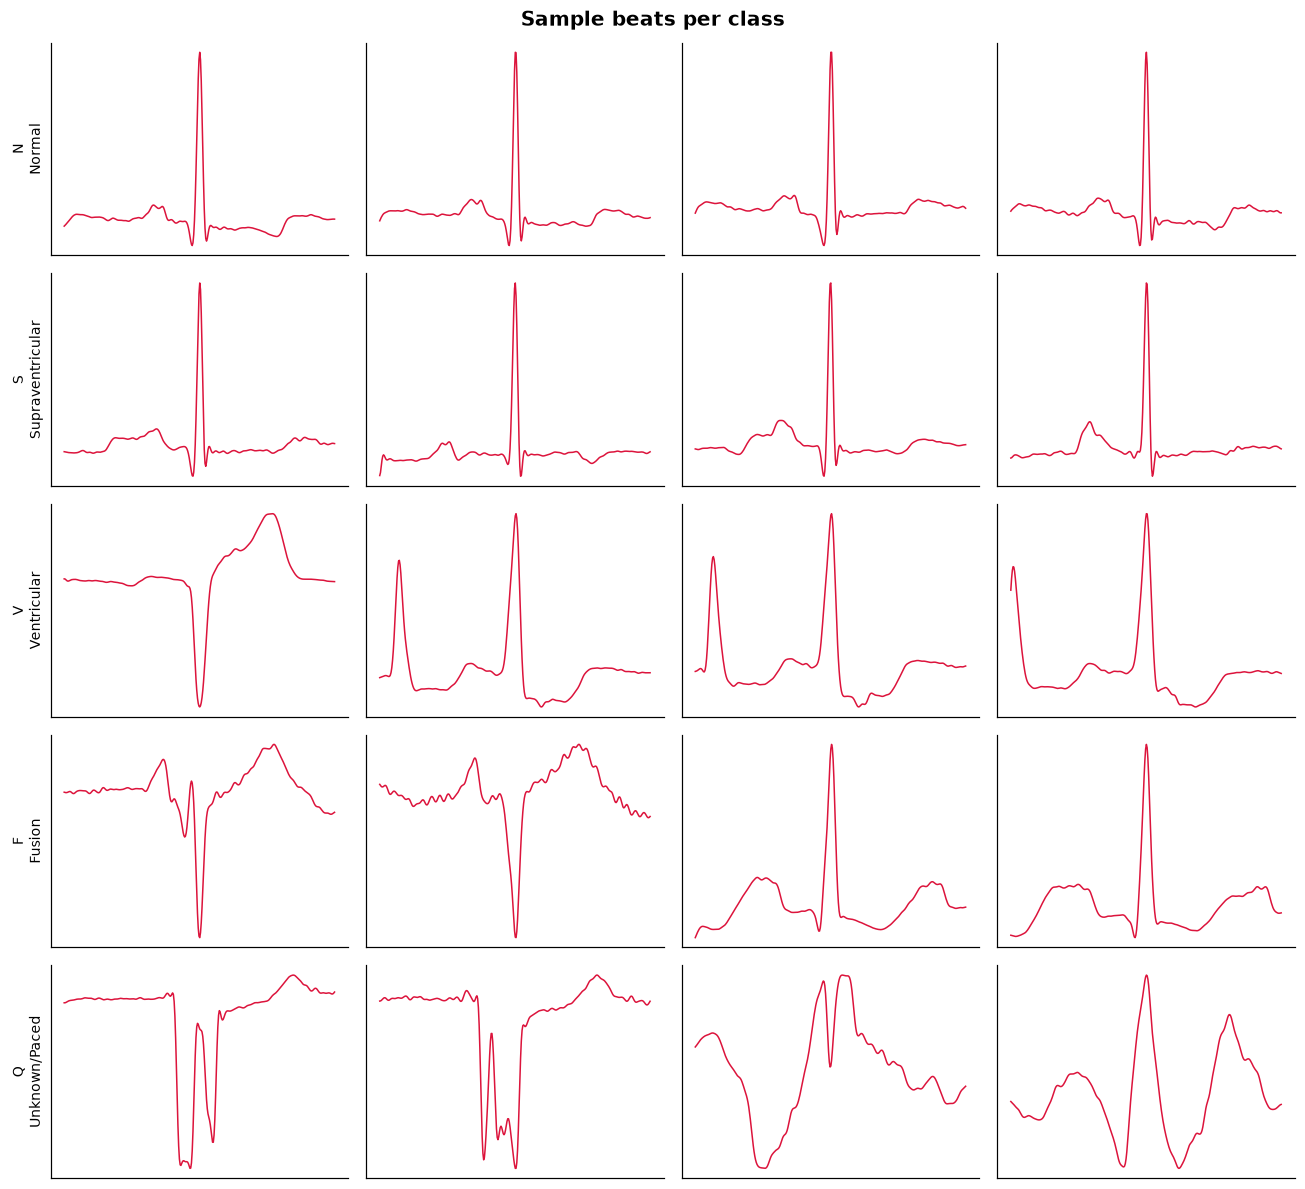

In [4]:
plot_sample_beats(signals, labels, n_per_class=4);

## 4. Average beat morphology per class

Averaging many beats of each class reveals the prototypical waveform the network must learn to separate.

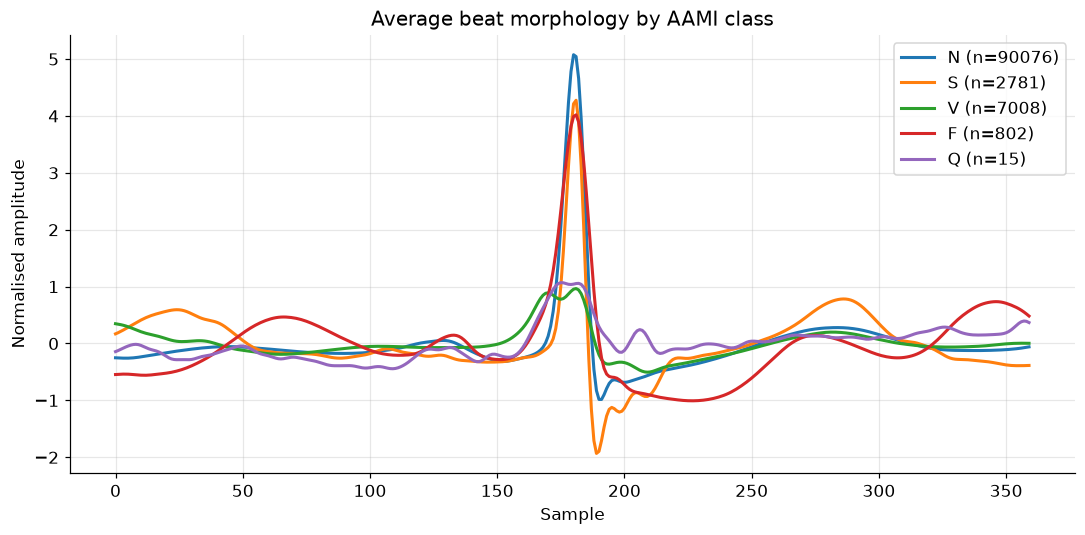

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, c in enumerate(AAMI_CLASSES):
    idx = np.where(labels == i)[0]
    if len(idx) == 0:
        continue
    mean_beat = signals[idx].mean(axis=0)
    ax.plot(mean_beat, label=f'{c} (n={len(idx)})', lw=2)
ax.set(title='Average beat morphology by AAMI class', xlabel='Sample', ylabel='Normalised amplitude')
ax.legend(); plt.tight_layout(); plt.show()